# 07. Составной процесс Пуассона

**Статус:** завершено

Составной процесс Пуассона описывает случайную сумму случайных скачков. Это естественная модель страховых выплат, операционных убытков, редких финансовых событий и суммарного PnL со скачками.

## Модель

Пусть $N(t)$ — пуассоновский процесс с интенсивностью $\lambda$, а $Y_1,Y_2,\dots$ — независимые размеры скачков. Тогда

$$S(t)=\sum_{i=1}^{N(t)}Y_i.$$

Здесь случайны две вещи: число скачков и размер каждого скачка. Если $m_1=\mathbb E[Y]$, $m_2=\mathbb E[Y^2]$, то

$$\mathbb E[S(t)]=\lambda t m_1,$$

$$\mathrm{Var}(S(t))=\lambda t m_2.$$

Важная интуиция: дисперсия зависит от второго момента скачка, а не только от дисперсии. Даже если средний скачок умеренный, тяжёлый правый хвост может делать суммарный риск большим.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

from Scripts.compound_poisson_process import (
    calculate_empirical_mean_and_variance,
    calculate_theoretical_compound_poisson_mean_and_variance,
    plot_compound_poisson_mean_variance,
    plot_compound_poisson_paths,
    plot_terminal_compound_poisson_distribution,
    simulate_compound_poisson_terminal_values,
    simulate_multiple_compound_poisson_process_paths,
)

## 1. Траектории со случайными скачками

,Показатель,Значение
0,E[S(5)] симуляция,17.8617
1,E[S(5)] теория,18.0000
2,Var[S(5)] симуляция,31.2997
3,Var[S(5)] теория,31.2000
4,5%-квантиль,9.3103
5,медиана,17.5137
6,95%-квантиль,27.6977


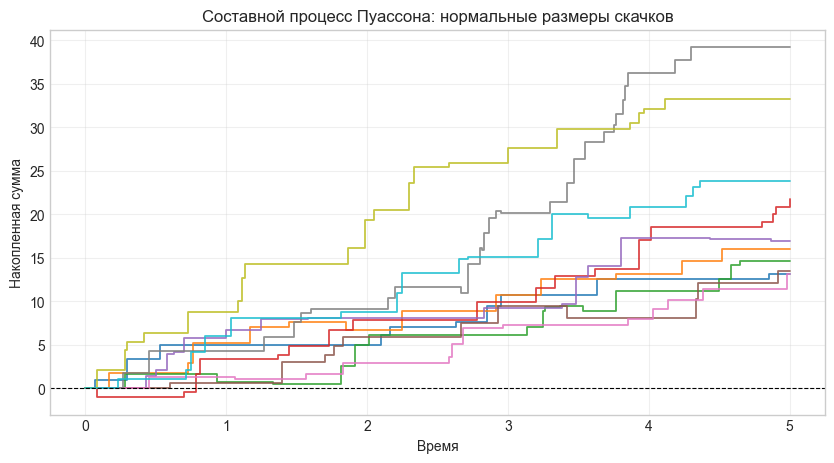

In [2]:
time_grid, compound_paths = simulate_multiple_compound_poisson_process_paths(
    number_of_paths=5000,
    number_of_time_steps=300,
    final_time=5.0,
    intensity=3.0,
    jump_mean=1.2,
    jump_standard_deviation=0.8,
    random_seed=123,
)
jump_second_moment = 1.2**2 + 0.8**2
theoretical_mean, theoretical_variance = calculate_theoretical_compound_poisson_mean_and_variance(time_grid, 3.0, 1.2, jump_second_moment)
empirical_mean, empirical_variance = calculate_empirical_mean_and_variance(compound_paths)
plot_compound_poisson_paths(time_grid, compound_paths, 10, "Составной процесс Пуассона: нормальные размеры скачков");

pd.DataFrame({
    "Показатель": ["E[S(5)] симуляция", "E[S(5)] теория", "Var[S(5)] симуляция", "Var[S(5)] теория", "5%-квантиль", "медиана", "95%-квантиль"],
    "Значение": [compound_paths[:,-1].mean(), theoretical_mean[-1], compound_paths[:,-1].var(), theoretical_variance[-1], *np.quantile(compound_paths[:,-1],[.05,.5,.95])]
})

Траектории ступенчатые, но скачки теперь имеют разные размеры и могут быть неравномерными. К моменту `T=5` среднее `17.8617` близко к теоретическому `18.0`, а дисперсия `31.2997` близка к `31.2`. Квантили `9.3103`, `17.5137`, `27.6977` показывают существенный разброс накопленной суммы.

## 2. Среднее, дисперсия и нормальная аппроксимация

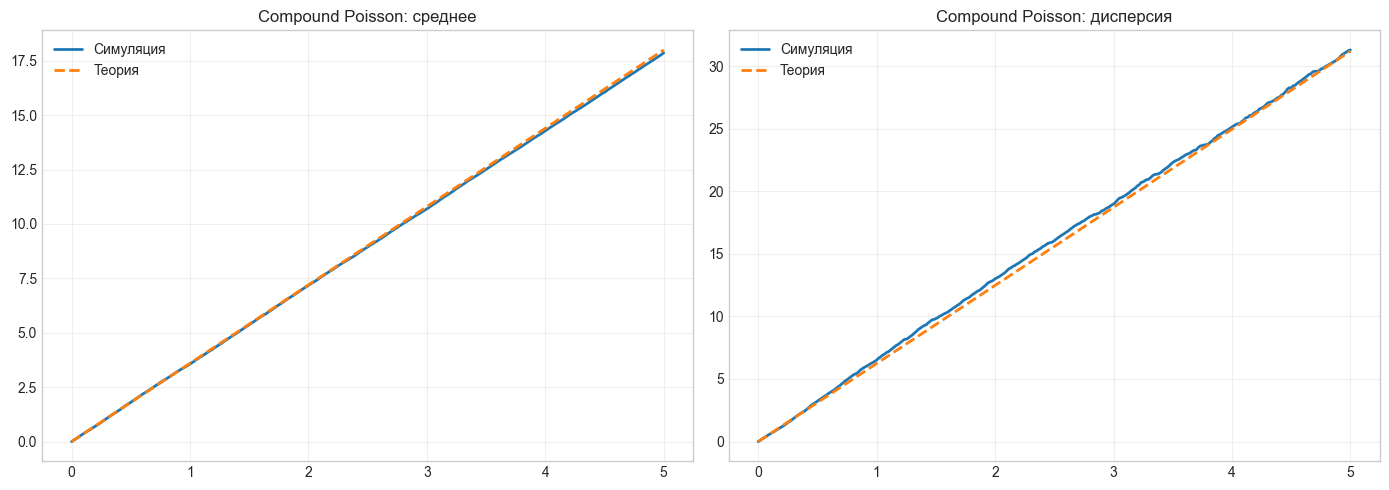

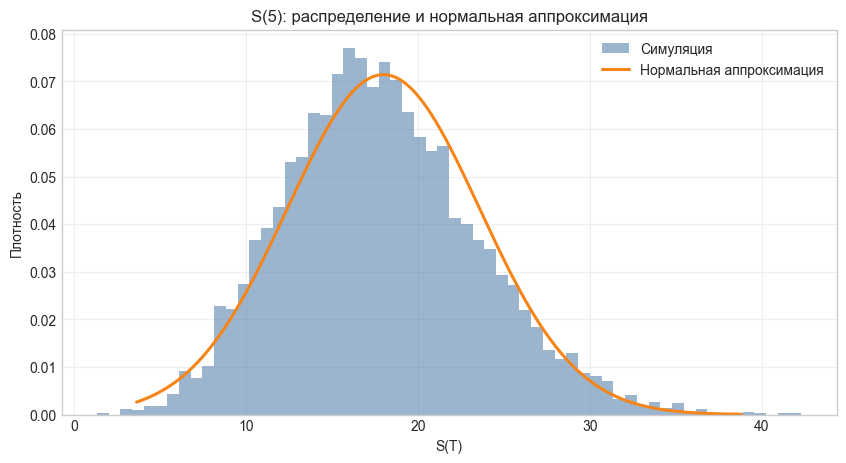

In [3]:
plot_compound_poisson_mean_variance(time_grid, empirical_mean, empirical_variance, theoretical_mean, theoretical_variance, "Compound Poisson");
plot_terminal_compound_poisson_distribution(compound_paths[:, -1], theoretical_mean[-1], theoretical_variance[-1], "S(5): распределение и нормальная аппроксимация");

Среднее и дисперсия растут линейно по времени, потому что за малый интервал добавляется независимый вклад новых скачков. Нормальная аппроксимация для терминального значения уже неплоха, но форма всё ещё может быть асимметричной или с тяжёлыми хвостами, если распределение скачков не нормальное или интенсивность мала.

## 3. Страховая модель с тяжёлыми выплатами

In [4]:
losses = simulate_compound_poisson_terminal_values(
    number_of_replications=8000,
    final_time=1.0,
    intensity=20.0,
    jump_sampler=lambda rng, n: rng.lognormal(mean=2.0, sigma=0.7, size=n),
    random_seed=321,
)

pd.DataFrame({
    "Показатель": ["Средний совокупный ущерб", "Дисперсия", "P(ущерб > 250)", "медиана", "95%-квантиль", "99%-квантиль"],
    "Значение": [losses.mean(), losses.var(), np.mean(losses > 250.0), *np.quantile(losses,[.5,.95,.99])]
})

,Показатель,Значение
0,Средний совокупный ущерб,189.6284
1,Дисперсия,3016.0254
2,P(ущерб > 250),0.1414
3,медиана,185.2680
4,95%-квантиль,285.6366
5,99%-квантиль,334.2145


В страховом примере средний совокупный ущерб около `189.6284`, но дисперсия огромна: `3016.0254`. Вероятность превысить уровень `250` равна `0.1414`, а 99%-квантиль `334.2145`. Это типичная картина для compound Poisson risk model: частота событий важна, но тяжесть хвоста размера выплаты часто важнее для капитала риска.

## Выводы

1. Составной процесс Пуассона складывает случайное число случайных скачков.
2. Среднее зависит от $\mathbb E[Y]$, а дисперсия от $\mathbb E[Y^2]$.
3. Модель естественно описывает совокупный ущерб, редкие события и скачкообразный PnL.
4. Тяжёлые хвосты размеров скачков резко увеличивают риск превышения высоких уровней.
5. Нормальная аппроксимация полезна при высокой интенсивности, но плохо описывает экстремальные хвосты.